<a href="https://colab.research.google.com/github/maazouziaicha-eng/Skin_Disease_Project/blob/main/Skin___Diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/ColabData/Skin_Disease_Project.zip'
extract_path = '/content/Skin_Disease_Project_Data'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
else:
    print("pret")

train_dir = None
test_dir = None

for root, dirs, files in os.walk(extract_path):
    if 'train' in dirs and train_dir is None:
        train_dir = os.path.join(root, 'train')
    if 'test' in dirs and test_dir is None:
        test_dir = os.path.join(root, 'test')

if train_dir and test_dir:
    print(train_dir)
    print(test_dir)

else:
    print("verifiez")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
pret
/content/Skin_Disease_Project_Data/Skin_Disease_Project/train
/content/Skin_Disease_Project_Data/Skin_Disease_Project/test


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('Exécution -> Modifier le type d\'exécution' )
else:
  print("GPU")

TensorFlow version: 2.19.0
GPU


In [40]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Telechargement des images")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print( {num_classes} )

y_train = np.concatenate([y for x, y in train_ds], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(enumerate(class_weights))

Telechargement des images
Found 13898 files belonging to 22 classes.
Using 11119 files for training.
Found 13898 files belonging to 22 classes.
Using 2779 files for validation.
Found 1546 files belonging to 22 classes.
{22}


Acne: 475 images
Actinic_Keratosis: 611 images
Benign_tumors: 859 images
Bullous: 404 images
Candidiasis: 196 images
DrugEruption: 435 images
Eczema: 797 images
Infestations_Bites: 423 images
Lichen: 452 images
Lupus: 250 images
Moles: 292 images
Psoriasis: 656 images
Rosacea: 204 images
Seborrh_Keratoses: 352 images
SkinCancer: 557 images
Sun_Sunlight_Damage: 259 images
Tinea: 740 images
Unknown_Normal: 1329 images
Vascular_Tumors: 421 images
Vasculitis: 361 images
Vitiligo: 572 images
Warts: 474 images


/tmp/ipykernel_573/2204920102.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[class_names[i] for i in unique_classes], y=counts, palette='magma')


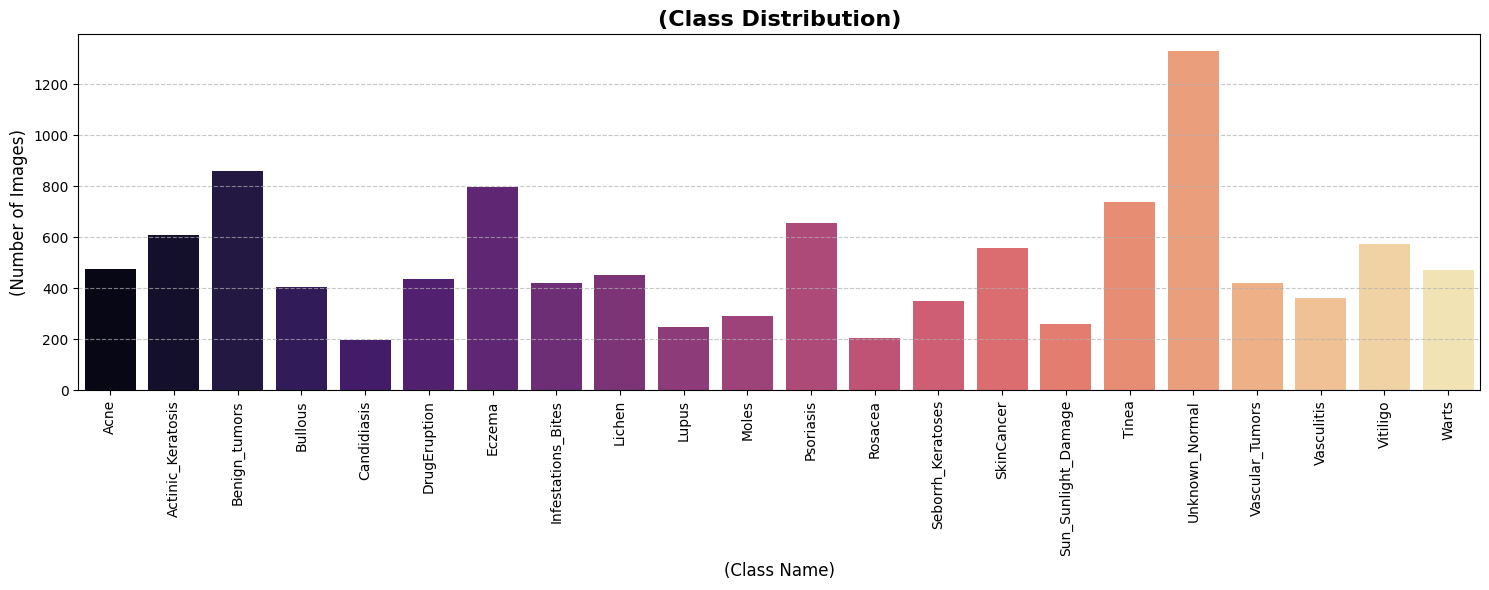

{max_class}) ={np.max(counts)} image


In [41]:
unique_classes, counts = np.unique(y_train, return_counts=True)

for i in range(len(unique_classes)):
    print(f"{class_names[unique_classes[i]]}: {counts[i]} images")
plt.figure(figsize=(15, 6))
sns.barplot(x=[class_names[i] for i in unique_classes], y=counts, palette='magma')

plt.title('(Class Distribution)', fontsize=16, fontweight='bold')
plt.xlabel('(Class Name)', fontsize=12)
plt.ylabel('(Number of Images)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

max_class = class_names[unique_classes[np.argmax(counts)]]
min_class = class_names[unique_classes[np.argmin(counts)]]
print("{max_class}) ={np.max(counts)} image")


In [42]:
import os
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

#Dataset2
balanced_train_dir = '/content/Dataset_2_Balanced'

if not os.path.exists(balanced_train_dir):
    os.makedirs(balanced_train_dir)

#(Generative AI Tool for Images)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

class_counts = {}
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

max_count = max(class_counts.values())
print({max_count} )

for class_name, count in class_counts.items():
    orig_class_dir = os.path.join(train_dir, class_name)
    new_class_dir = os.path.join(balanced_train_dir, class_name)

    if not os.path.exists(new_class_dir):
        os.makedirs(new_class_dir)

    image_files = os.listdir(orig_class_dir)
    for img_file in image_files:
        src = os.path.join(orig_class_dir, img_file)
        dst = os.path.join(new_class_dir, img_file)
        shutil.copy(src, dst)

    images_to_generate = max_count - count
    if images_to_generate > 0:
        print(f"genarate dataset2 {images_to_generate} for ({class_name})...")
        images_for_aug = [os.path.join(orig_class_dir, f) for f in image_files]

        generated = 0
        while generated < images_to_generate:
            for img_path in images_for_aug:
                if generated >= images_to_generate:
                    break

                try:
                    img = load_img(img_path)
                    x = img_to_array(img)
                    x = x.reshape((1,) + x.shape)

                    for batch in datagen.flow(x, batch_size=1, save_to_dir=new_class_dir, save_prefix='AI_gen', save_format='jpg'):
                        generated += 1
                        break
                except:
                    continue

print("Terminée")

{1651}
genarate dataset2 1339 for (Sun_Sunlight_Damage)...
genarate dataset2 728 for (Tinea)...
genarate dataset2 1403 for (Candidiasis)...
genarate dataset2 958 for (SkinCancer)...
genarate dataset2 1071 for (Warts)...
genarate dataset2 1340 for (Lupus)...
genarate dataset2 1147 for (Bullous)...
genarate dataset2 641 for (Eczema)...
genarate dataset2 1098 for (Lichen)...
genarate dataset2 937 for (Vitiligo)...
genarate dataset2 1108 for (Vascular_Tumors)...
genarate dataset2 1397 for (Rosacea)...
genarate dataset2 1196 for (Seborrh_Keratoses)...
genarate dataset2 1190 for (Vasculitis)...
genarate dataset2 1290 for (Moles)...
genarate dataset2 903 for (Actinic_Keratosis)...
genarate dataset2 1058 for (Acne)...
genarate dataset2 1127 for (Infestations_Bites)...
genarate dataset2 831 for (Psoriasis)...
genarate dataset2 1104 for (DrugEruption)...
genarate dataset2 558 for (Benign_tumors)...
Terminée


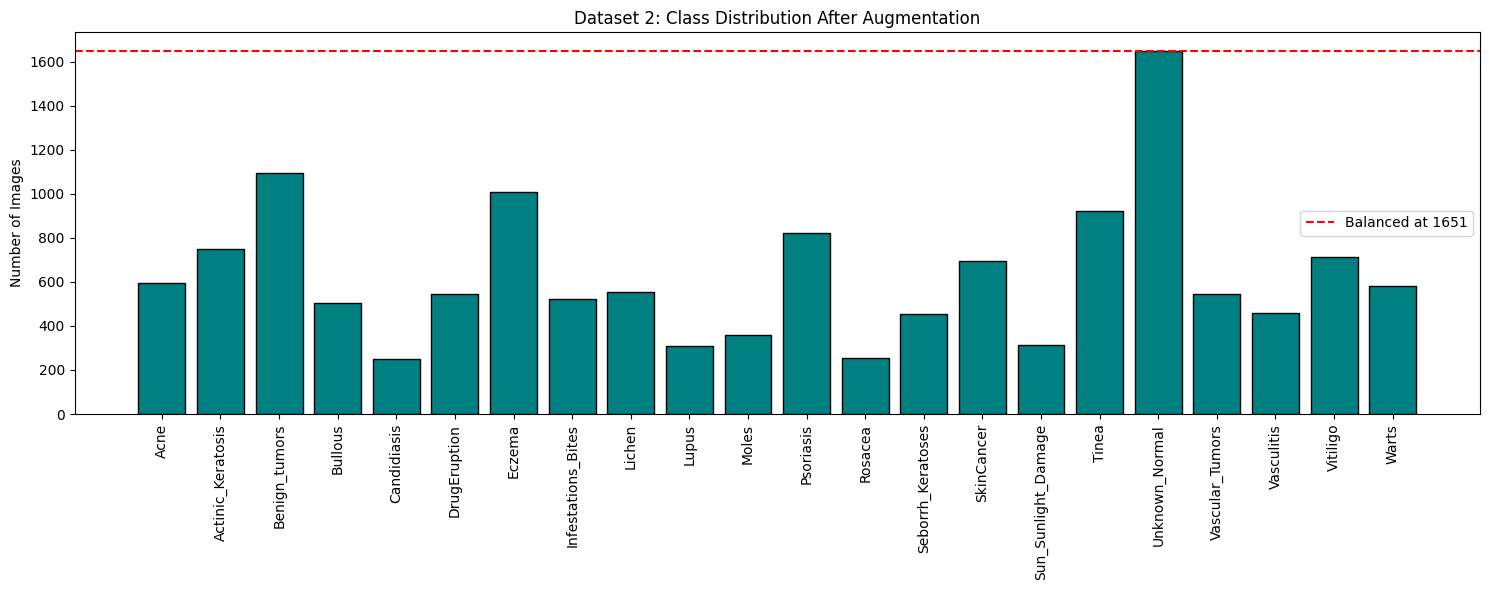

In [43]:
import os
import matplotlib.pyplot as plt

train_dir = '/content/Skin_Disease_Project_Data/Skin_Disease_Project/train'

if os.path.exists(train_dir):
    categories = sorted(os.listdir(train_dir))
    counts = [len(os.listdir(os.path.join(train_dir, c))) for c in categories if os.path.isdir(os.path.join(train_dir, c))]

    plt.figure(figsize=(15, 6))
    plt.bar(categories, counts, color='teal', edgecolor='black')
    plt.axhline(y=max(counts), color='red', linestyle='--', label=f'Balanced at {max(counts)}')
    plt.title('Dataset 2: Class Distribution After Augmentation')
    plt.xticks(rotation=90)
    plt.ylabel('Number of Images')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [44]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

print("Chargement des donnees en memoire...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir, validation_split=0.2, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir, validation_split=0.2, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Calcul des poids de classes...")
y_train = np.concatenate([y for x, y in train_ds], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = dict(enumerate(class_weights))

print("Preparation des donnees terminee.")

Chargement des donnees en memoire...
Found 54021 files belonging to 22 classes.
Using 43217 files for training.
Found 54021 files belonging to 22 classes.
Using 10804 files for validation.
Found 1546 files belonging to 22 classes.
Calcul des poids de classes...
Preparation des donnees terminee.


In [45]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Phase 1 : Echauffement du modele (5 epoques)...")
history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=weight_dict
)

Phase 1 : Echauffement du modele (5 epoques)...
Epoch 1/5
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 187s 65ms/step - accuracy: 0.3323 - loss: 2.3048 - val_accuracy: 0.4569 - val_loss: 1.7762
Epoch 2/5
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 156s 58ms/step - accuracy: 0.3969 - loss: 2.0283 - val_accuracy: 0.4736 - val_loss: 1.7052
Epoch 3/5
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 145s 54ms/step - accuracy: 0.4017 - loss: 2.0229 - val_accuracy: 0.4887 - val_loss: 1.6561
Epoch 4/5
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 202s 54ms/step - accuracy: 0.4074 - loss: 2.0101 - val_accuracy: 0.4845 - val_loss: 1.6689
Epoch 5/5
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 222s 61ms/step - accuracy: 0.4100 - loss: 2.0135 - val_accuracy: 0.4761 - val_loss: 1.6880


In [ ]:
import os
import matplotlib.pyplot as plt

balanced_path = '/content/Dataset_2_Balanced'

if os.path.exists(balanced_path):
    folders = sorted(os.listdir(balanced_path))
    counts = []
    names = []

    for folder in folders:
        folder_path = os.path.join(balanced_path, folder)
        if os.path.isdir(folder_path):
            names.append(folder)
            counts.append(len(os.listdir(folder_path)))

    plt.figure(figsize=(15, 7))
    bars = plt.bar(names, counts, color='skyblue', edgecolor='navy')

    plt.axhline(y=max(counts), color='red', linestyle='--', label=f'Balanced at {max(counts)} images')

    plt.title('Dataset 2: Perfect Class Balancing (After AI Augmentation)', fontsize=16)
    plt.xlabel('Skin Disease Categories', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.xticks(rotation=90)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
    print(f"Total Categories: {len(names)}")
    print(f"Images per Category: {counts}")
else:
    print("path!!!")

In [46]:
print("Phase 2 : Fine-Tuning des couches profondes...")
base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

print("Lancement de l'entrainement profond...")
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=weight_dict,
    callbacks=[early_stopping, reduce_lr]
)

Phase 2 : Fine-Tuning des couches profondes...
Lancement de l'entrainement profond...
Epoch 1/25
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 197s 64ms/step - accuracy: 0.3147 - loss: 2.4206 - val_accuracy: 0.4660 - val_loss: 1.7390 - learning_rate: 1.0000e-05
Epoch 2/25
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 151s 56ms/step - accuracy: 0.4279 - loss: 1.8449 - val_accuracy: 0.5289 - val_loss: 1.5214 - learning_rate: 1.0000e-05
Epoch 3/25
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 166s 62ms/step - accuracy: 0.4888 - loss: 1.6377 - val_accuracy: 0.5746 - val_loss: 1.3672 - learning_rate: 1.0000e-05
Epoch 4/25
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 152s 56ms/step - accuracy: 0.5352 - loss: 1.4801 - val_accuracy: 0.6104 - val_loss: 1.2468 - learning_rate: 1.0000e-05
Epoch 5/25
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 214s 61ms/step - accuracy: 0.5752 - loss: 1.3492 - val_accuracy: 0.6431 - val_loss: 1.1458 - learning_rate: 1.0000e-05
Epoch 6/25
2702/2702 ━━━━━━━━━━━━━━━━━━━━ 206s 62ms/step - accuracy: 0.6068 - loss: 1.2369 - val_accuracy: 0.

Evaluation finale sur le jeu de test (donnees invisibles)...
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.6585 - loss: 1.5807
(Test Accuracy) : 65.85%

Generation des predictions pour la matrice de confusion...
97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step


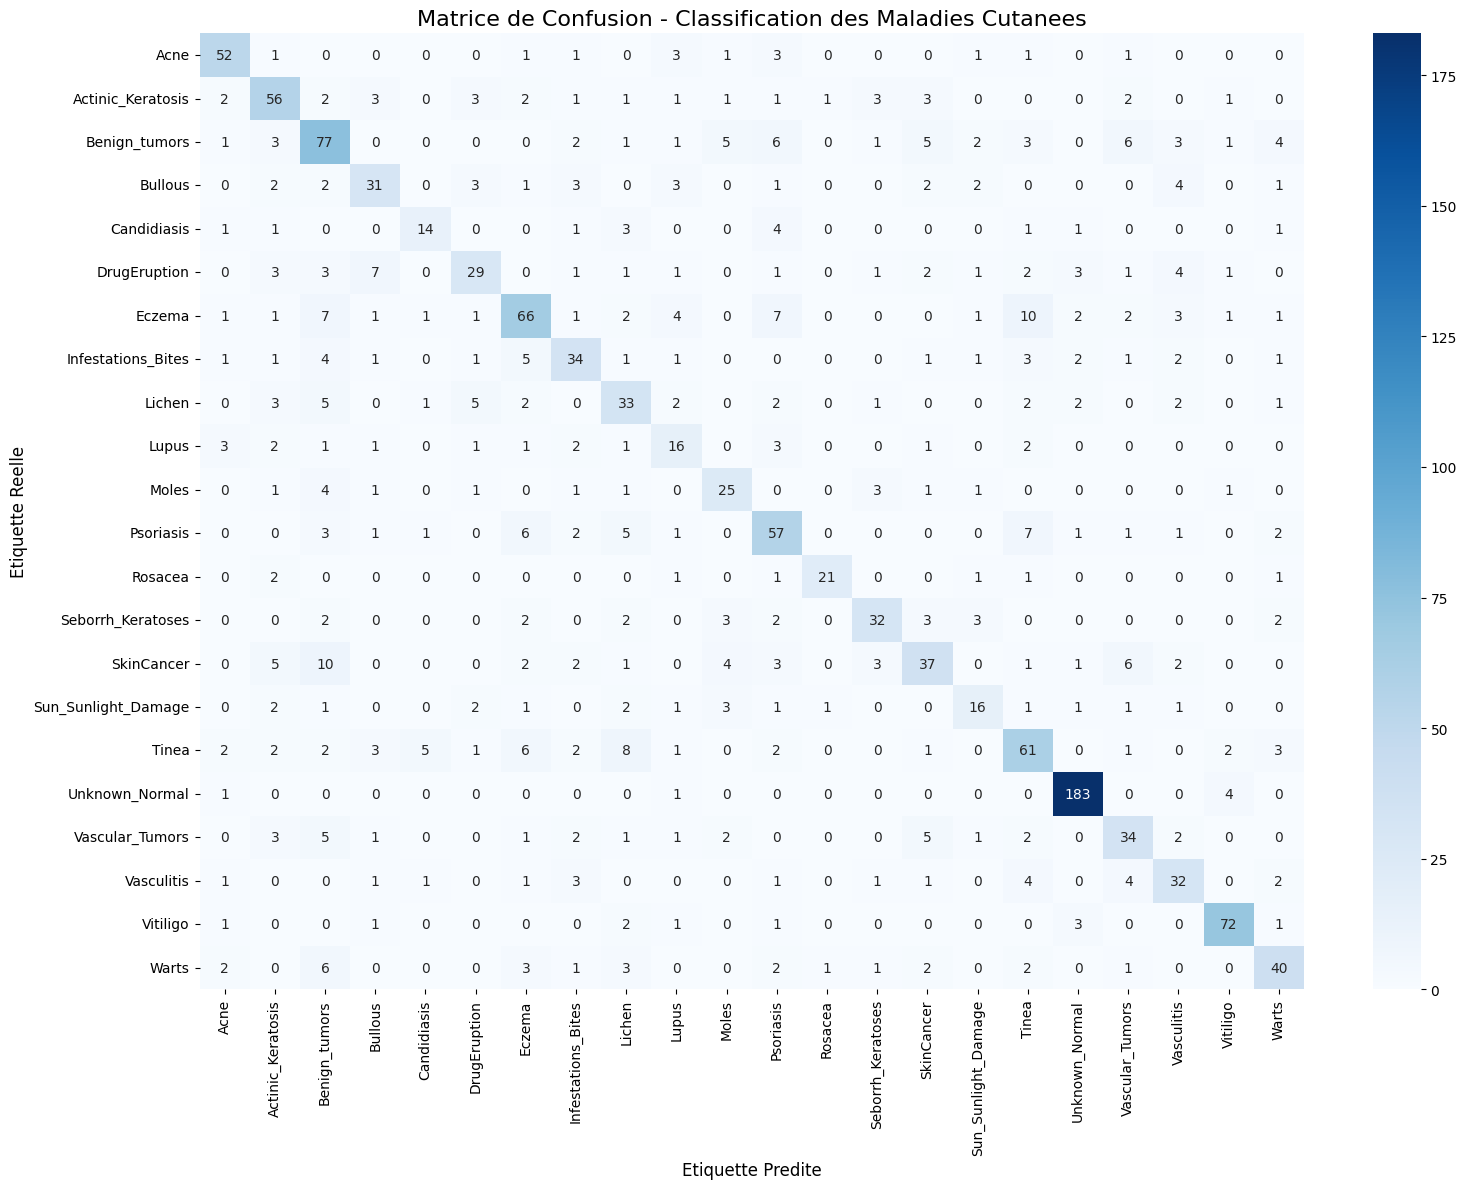


--- Rapport de Classification Detaille ---
                     precision    recall  f1-score   support

               Acne       0.76      0.80      0.78        65
  Actinic_Keratosis       0.64      0.67      0.65        83
      Benign_tumors       0.57      0.64      0.60       121
            Bullous       0.60      0.56      0.58        55
        Candidiasis       0.61      0.52      0.56        27
       DrugEruption       0.62      0.48      0.54        61
             Eczema       0.66      0.59      0.62       112
 Infestations_Bites       0.58      0.57      0.57        60
             Lichen       0.49      0.54      0.51        61
              Lupus       0.41      0.47      0.44        34
              Moles       0.57      0.62      0.60        40
          Psoriasis       0.58      0.65      0.61        88
            Rosacea       0.88      0.75      0.81        28
  Seborrh_Keratoses       0.70      0.63      0.66        51
         SkinCancer       0.58      0.48

In [47]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluation finale sur le jeu de test (donnees invisibles)...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"(Test Accuracy) : {test_acc*100:.2f}%\n")

print("Generation des predictions pour la matrice de confusion...")
predictions = model.predict(test_ds)
y_pred = np.argmax(predictions, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Matrice de Confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - Classification des Maladies Cutanees', fontsize=16)
plt.ylabel('Etiquette Reelle', fontsize=12)
plt.xlabel('Etiquette Predite', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Rapport de Classification
print("\n--- Rapport de Classification Detaille ---")
print(classification_report(y_true, y_pred, target_names=class_names))
